# Notebook for testing aspects of the Diffusers library
Current list of sections:
1. VAE

## VAE

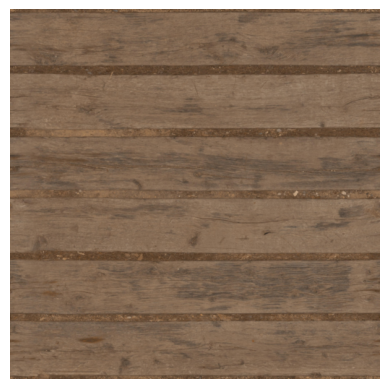

Latents shape: torch.Size([1, 4, 64, 64])
Reconstructed image shape: torch.Size([1, 3, 512, 512])


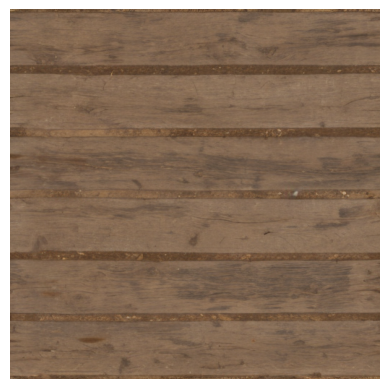

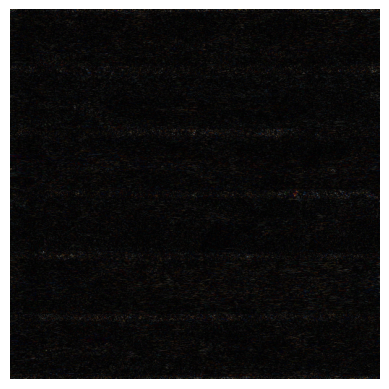

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.260007..11.509569].


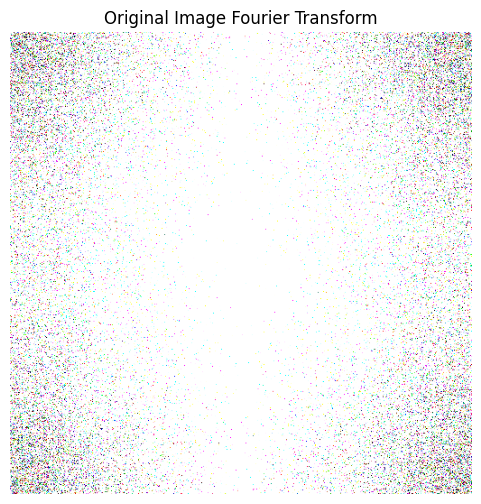

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.243176..11.524562].


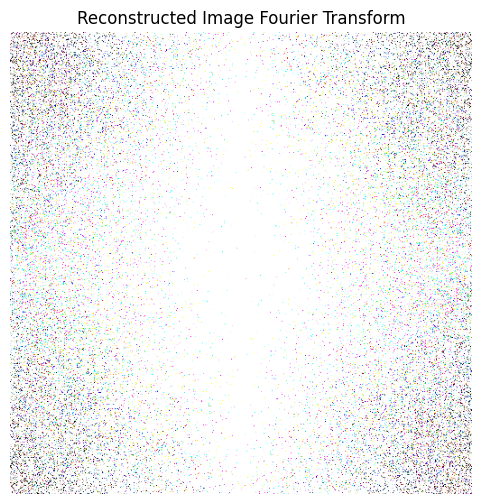

In [3]:
# Change working directory to parent directory
import os
os.chdir("/media/aris/Data/master2025dev/aris_master")
device = "cuda"
from diffusers import AutoencoderKL

# # --------------------------- import model locally --------------------------- #
local_model_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
local_model_path2 = os.path.join(os.getcwd(), "models/VAE/stable-diffusion-v1-5-vae")
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to(device)
vae2 = AutoencoderKL.from_pretrained(local_model_path2)
vae2.to(device)

# # Test the model by printing its configuration
# print("Model configuration:", model.config)

# Test the model with image
img_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
img_path = "/media/aris/Data/master2025dev/Textures/dirty_wood_planks__Diffuse_.jpg"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
image = transform(image).unsqueeze(0).to(device)

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_input.png"
save_path = "/media/aris/Data/master2025dev/outputs/VAE_half_res_test_output.png"
dirname = os.path.dirname(save_path)
os.makedirs(dirname, exist_ok=True)
#Limit image to valid range and convert to PIL
img = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
img = transforms.ToPILImage()(img)
img.save(save_path)


# plot image 
import matplotlib.pyplot as plt
plt.imshow((image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()
# latents = model.encode(image)


# ---------------------------------- encode ---------------------------------- #
import torch    
with torch.no_grad():
    latents = vae.encode(image).latent_dist.sample()
print("Latents shape:", latents.shape)

# ---------------------------------- decode ---------------------------------- #
with torch.no_grad():
    reconstructed_image = vae.decode(latents).sample
    
print("Reconstructed image shape:", reconstructed_image.shape)
# plot reconstructed image
plt.imshow((reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()

#save
save_path = "/media/aris/Data/master2025dev/outputs/VAE_half_res_test_output.png"
dirname = os.path.dirname(save_path)
os.makedirs(dirname, exist_ok=True)
#Limit image to valid range and convert to PIL
img = (reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
reconstructed_image_pil = transforms.ToPILImage()(img)
reconstructed_image_pil.save(save_path)


#Plot thedifference between the original and reconstructed image
difference = (image - reconstructed_image).abs().squeeze(0).permute(1, 2, 0).cpu().numpy()
plt.imshow(difference)
plt.axis('off')
plt.show()

#Calculate the fourier transform of the original and reconstructed image
import numpy as np
def plot_fourier_transform(image, title):
    # Convert to numpy and move channels to last dimension
    img_np = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    # Calculate the Fourier transform
    f_transform = np.fft.fft2(img_np, axes=(0, 1))
    f_shifted = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shifted) + 1e-8)  # Add small value to avoid log(0)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(magnitude_spectrum)
    plt.title(title)
    plt.axis('off')
    plt.show()
plot_fourier_transform(image, "Original Image Fourier Transform")
plot_fourier_transform(reconstructed_image, "Reconstructed Image Fourier Transform")



#vae.to("cpu")




## Debugging attempt of the green hue of the VAE
I suspect the green hue of the vae could come from the transform in the dataloader. Following code takes the dataloader and visualises the vae input-output

In [ ]:
resolution = (128,128)
center_crop = True
random_flip = True
preserve_input_precision = False
train_batch_size = 4
dataloader_num_workers = 4
dataset_dir = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/"

import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

def preview_dataloader(dataloader, num_images=8):
    """
    Preview images from the dataloader in a grid.
    
    Args:
        dataloader: PyTorch DataLoader object
        num_images: Number of images to display (default: 8)
    """
    # Get a batch from the dataloader
    batch = next(iter(dataloader))
    images = batch["input"]
    
    # Limit to num_images
    images = images[:num_images]
    
    # Denormalize images from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = torch.clamp(images, 0, 1)
    
    # Create grid
    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(5,5))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx < len(images):
            # Convert to numpy and transpose from CxHxW to HxWxC
            img = images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()


augmentations = transforms.Compose(
    [
        transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform_images(examples):
    processed = []
    for image in examples["image"]:
        processed.append(augmentations(image.convert("RGB")))
    return {"input": processed}

from datasets import load_dataset
# Load the dataset
dataset = load_dataset("imagefolder", data_dir=dataset_dir, split="train")
    

dataset.set_transform(transform_images)
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=train_batch_size, shuffle=True, num_workers=dataloader_num_workers
)
preview_dataloader(train_dataloader, num_images=4)






In [ ]:


# ---------------------------------- ENCODE ---------------------------------- #
# Get the first batch of images from the dataloader
test_batch = train_dataloader.dataset[0:train_batch_size]  # Get the first batch of images
print(f"Test batch keys: {test_batch.keys()}")
input_images = torch.tensor(np.array(test_batch["input"])).to("cuda")

print(f"Test images shape: {input_images.shape}, Test images min: {input_images.min().item()}, Test images max: {input_images.max().item()}, Test images dtype: {input_images.dtype}")

with torch.no_grad():
    latent_dist = vae.encode(input_images).latent_dist
    latents = latent_dist.sample()
    latents2 = latent_dist.sample()
    
print("STUPID CHECK: are the two samples different?", not torch.equal(latents, latents2))
print(type(latent_dist), type(latents))
print(f"Latent distribution mean shape: {latent_dist.mean.shape}, Latent distribution std shape: {latent_dist.std.shape}")
print("Mean of latent distribution:", latent_dist.mean)
print("Std of latent distribution:", latent_dist.std)

print(f"Latent shape: {latents.shape}, Latent min: {latents.min().item()}, Latent max: {latents.max().item()}, Latent dtype: {latents.dtype}")
latents = latents * vae.config.scaling_factor
print(f"Latents shape after scaling: {latents.shape}, Latent min: {latents.min().item()}, Latent max: {latents.max().item()}, Latent dtype: {latents.dtype}")
latents_tmp = latents.cpu()

# ------------------------- PLOT HISTOGAM OF LATENTS ------------------------- #
import matplotlib.pyplot as plt
import numpy as np
# Flatten the latents to 1D
latents_flat = latents.cpu().numpy().flatten()
# Plot histogram
plt.figure(figsize=(6, 5))
plt.hist(latents_flat, bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Latent Values')
plt.xlabel('Latent Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(-5, 5)  # Set x-axis limits to focus on the range of interest
plt.show()

In [ ]:
# ------------------------------ MODIFY LATENTS ------------------------------ #

latents = latents_tmp

# scale = 0.5
# latents = torch.clamp(latents, -scale, scale)

noise = torch.randn_like(latents) * 0.1  # Adjust the noise scale as needed
latents = latents + noise


# ---------------------------- MODIFY LATENTS END ---------------------------- #


# ---------------------------------- Decode ---------------------------------- #
print("Latents shape:", latents.shape)
# decode the latents with VAE in smaller batches to avoid OOM
decoded_images = []
vae_batch_size = 4  # Process 4 images at a time
with torch.no_grad():
    for i in range(0, len(latents), vae_batch_size):
        batch = latents[i:i+vae_batch_size] / vae.config.scaling_factor
        
        if not isinstance(batch, torch.Tensor):
            batch = torch.from_numpy(batch)
        # batch = batch.permute(0, 3, 1, 2).contiguous()
        print("batch shape:", batch.shape)
        decoded_batch = vae2.decode(batch.to(vae.device), return_dict=False)[0]
        decoded_images.append(decoded_batch.cpu())
        del batch, decoded_batch
        torch.cuda.empty_cache()
output_images = torch.cat(decoded_images, dim=0)
print("Final decoded images shape:", output_images.shape)

#Plot decoded images
# Limit to num_images
num_images = 4
output_images = output_images[:num_images]

# Denormalize images from [-1, 1] to [0, 1]
output_images = (output_images + 1) / 2
output_images = torch.clamp(output_images, 0, 1)

input_images_plot =  (input_images.to("cpu") + 1) / 2
input_images_plot = torch.clamp(input_images_plot, 0, 1)

# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, 2*grid_size, figsize=(8, 5))
axes = axes.flatten()
axes[1].set_title("Original Images", fontsize=8)
axes[5].set_title("Decoded Images from VAE", fontsize=8)

for idx, ax in enumerate(axes):
    if idx < len(output_images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = input_images_plot[idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
    elif idx < 2*len(output_images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = output_images[idx - len(output_images)].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## Warped latents:
# map the latents to the range [0-1] from [-12,12]
warped_latents = (latents - latents.min()) / (latents.max() - latents.min())
# warped_latents = latents



print("Warped latents shape:", warped_latents.shape, "Warped latents min:", warped_latents.min().item(), "Warped latents max:", warped_latents.max().item(), "Warped latents dtype:", warped_latents.dtype)

warped_latents = warped_latents/ vae.config.scaling_factor
# Decode
with torch.no_grad():
    warped_images = vae.decode(warped_latents, return_dict=False)[0]

print("Warped images shape:", warped_images.shape, "Warped images min:", warped_images.min().item(), "Warped images max:", warped_images.max().item(), "Warped images dtype:", warped_images.dtype)


# Denormalize images from [-1, 1] to [0, 1]
warped_images = (warped_images.detach() + 1) / 2
warped_images = torch.clamp(warped_images, 0, 1)

# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(warped_images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = warped_images[idx].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
## Create a normal diffusion pipeline with untrained weights
from diffusers import DDIMScheduler, DDIMPipeline, UNet2DModel
from src.waste_diffuser.pipeline import Pipeline

num_train_timesteps = 1000
beta_schedule = "linear"
prediction_type = "epsilon"

scheduler = DDIMScheduler(
        num_train_timesteps=num_train_timesteps,
        beta_schedule=beta_schedule,
        prediction_type=prediction_type,
    )

config_path = "/media/aris/Data/master2025dev/aris_master/scripts/config_template.json"
config = UNet2DModel.load_config(config_path)
model = UNet2DModel.from_config(config["model"])
num_classes = config["model"]["num_class_embeds"]

pipeline = DDIMPipeline(
    unet=model,
    scheduler=scheduler,
)
pipeline.to("cuda")
generator = torch.Generator(device=pipeline.device).manual_seed(0)

batch_size = 4
interence_steps = 50
latents = pipeline(
    generator=generator,
    batch_size=batch_size,
    num_inference_steps=interence_steps,
    output_type="latent",
    return_dict=False
)[0]
print("Latents shape:", latents.shape, "Latents min:", latents.min().item(), "Latents max:", latents.max().item(), "datatype:", latents.dtype)

# Denormalize images from [-1, 1] to [0, 1]
latents = (latents + 1) / 2
print("Latents shape:", latents.shape, "Latents min:", latents.min().item(), "Latents max:", latents.max().item(), "datatype:", latents.dtype)
latents = torch.tensor(latents, dtype=torch.float32)
latents = torch.clamp(latents, 0, 1)

In [ ]:


# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(latents):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = latents[idx].numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
config_path = "/media/aris/Data/master2025dev/aris_master/scripts/config_vae.json"
config = UNet2DModel.load_config(config_path)
model = UNet2DModel.from_config(config["model"])
num_classes = config["model"]["num_class_embeds"]

pipeline = Pipeline(
    unet=model,
    scheduler=scheduler,
)
pipeline.to("cuda")
generator = torch.Generator(device=pipeline.device).manual_seed(0)

batch_size = 4
interence_steps = 50
with torch.no_grad():
    latents_vae = pipeline(
        generator=generator,
        batch_size=batch_size,
        num_inference_steps=interence_steps,
        output_type="latent",
        return_dict=False
    )[0]
    
    
# ------------------------- PLOT HISTOGAM OF LATENTS ------------------------- #
import matplotlib.pyplot as plt
import numpy as np
# Flatten the latents to 1D
latents_flat = latents_vae.flatten().cpu().numpy()
# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(latents_flat, bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Latent Values')
plt.xlabel('Latent Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(-5, 5)  # Set x-axis limits to focus on the range of interest
plt.show()

print("Latents_vae shape:", latents_vae.shape, "Latents_vae min:", latents_vae.min().item(), "Latents_vae max:", latents_vae.max().item(), "datatype:", latents_vae.dtype)

In [ ]:
# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(latents_vae):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = latents_vae[idx].numpy()
        # clip to 3 channels
        img = img[:, :, :3]
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Run through VAE
latents_vae_permuted = latents_vae/vae.config.scaling_factor/vae.config.scaling_factor
print("Latents shape after permute:", latents_vae_permuted.shape, "Latents min:", latents_vae_permuted.min().item(), "Latents max:", latents_vae_permuted.max().item(), "datatype:", latents_vae_permuted.dtype)
images = vae.decode(latents_vae_permuted.to(vae.device), return_dict=False)[0]
print("Decoded images shape:", images.shape, "Decoded images min:", images.min().item(), "Decoded images max:", images.max().item(), "Decoded images dtype:", images.dtype)


In [ ]:
# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = images[idx].detach().cpu().numpy()
        # permute from CxHxW to HxWxC
        img = np.transpose(img, (1, 2, 0))
        # clip to 3 channels
        img = img[:, :, :3]
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

## Unet2DConditionModel
Following code attempts to create a Unet2DConditionModel and apply it

In [ ]:
# from diffusers import UNet2DConditionModel
# local_model_path = os.path.join(os.getcwd(), "models/UNet/runwayml-stable-diffusion-v1-5")
# unet = UNet2DConditionModel.from_pretrained(local_model_path)

# unet.to(device)
# print("UNet model loaded successfully.")
# #print model config
# print("Model configuration:", unet.config)


# #Map image to latents
# latents = vae.encode(image)

# print("Latents shape:", latents.latent_dist.sample().shape)

# output_latents = unet(latents.latent_dist.sample(), timestep=10, encoder_hidden_states=torch.randn(1, 77, 768).to(device))
# print("Output latents shape:", output_latents.sample.shape)

In [ ]:
# from diffusers import UNet2DModel

# path = "/media/aris/Data/master2025dev/aris_master/training/07-02_2-class-conditioning-wood-plastic_128/unet/config.json"
# config = UNet2DModel.load_config(path)
# print("UNet configuration:", config)
# model = UNet2DModel.from_config(config)
# print("UNet model loaded successfully.")



In [ ]:
import torch

## optimizer and scheduler debugging
scheduler_path = "/media/aris/Data/master2025dev/aris_master/training/02-17_VAE_128/checkpoint-90000/scheduler.bin"
optimizer_path = "/media/aris/Data/master2025dev/aris_master/training/02-17_VAE_128/checkpoint-90000/optimizer.bin"

scheduler_state = torch.load(scheduler_path)
# optimizer_state = torch.load(optimizer_path)

print("Scheduler state keys:", scheduler_state.keys())
print("Scheduler state:", scheduler_state)
# print("\nOptimizer state keys:", optimizer_state.keys())
# print("Optimizer state:", optimizer_state)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

In [ ]:
from datasets import load_dataset

ds = load_dataset("pcuenq/lsun-bedrooms", split="train")
ds.set_transform(transform_images)
train_dataloader = torch.utils.data.DataLoader(
    ds, batch_size=train_batch_size, shuffle=True, num_workers=dataloader_num_workers
)
print("train_dataloader:", train_dataloader)
preview_dataloader(train_dataloader, num_images=4)

In [ ]:
model_path = "/media/aris/Data/master2025dev/aris_master/models/VAE/kl-f4/model.ckpt"

model = AutoencoderKL.from_pretrained(model_path)